In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("데이터셋.xlsx")

In [3]:
print(df.head())

   batch_k      보닛      도어      지붕     트렁크    X_Sum     X_bar      R  \
0        1  40.932  40.158  43.700  41.970  166.760  41.69000  3.542   
1        2  38.730  41.286  42.390  43.479  165.885  41.47125  4.749   
2        3  42.164  38.687  41.227  41.412  163.490  40.87250  3.477   
3        4  36.522  36.308  41.867  38.457  153.154  38.28850  5.559   
4        5  39.792  36.399  40.584  42.570  159.345  39.83625  6.171   

   is_anomaly_zone 스프레이압력 담당조  부스온도_실측  온도  
0            False     고압  B조    23.87  정상  
1            False     저압  B조    23.92  정상  
2            False     저압  A조    23.76  정상  
3            False     고압  C조    22.71  정상  
4            False     중압  A조    22.81  정상  


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   batch_k          50 non-null     int64  
 1   보닛               50 non-null     float64
 2   도어               50 non-null     float64
 3   지붕               50 non-null     float64
 4   트렁크              50 non-null     float64
 5   X_Sum            50 non-null     float64
 6   X_bar            50 non-null     float64
 7   R                50 non-null     float64
 8   is_anomaly_zone  50 non-null     bool   
 9   스프레이압력           50 non-null     object 
 10  담당조              50 non-null     object 
 11  부스온도_실측          50 non-null     float64
 12  온도               50 non-null     object 
dtypes: bool(1), float64(8), int64(1), object(3)
memory usage: 4.9+ KB


In [5]:
df.isnull().sum() #결측치 여부 확인

batch_k            0
보닛                 0
도어                 0
지붕                 0
트렁크                0
X_Sum              0
X_bar              0
R                  0
is_anomaly_zone    0
스프레이압력             0
담당조                0
부스온도_실측            0
온도                 0
dtype: int64

In [6]:
df.describe()

,batch_k,보닛,도어,지붕,트렁크,X_Sum,X_bar,R,부스온도_실측
count,50.00000,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,25.50000,40.146820,38.84080,41.870820,40.786520,161.644960,40.411240,4.297240,23.351600
std,14.57738,1.910978,1.77751,1.383449,2.110109,4.466921,1.116730,1.828593,1.009777
min,1.00000,36.522000,34.43900,38.380000,36.622000,152.631000,38.157750,1.025000,21.220000
25%,13.25000,39.002250,37.42000,41.084750,39.325250,159.342750,39.835688,2.830250,22.802500
50%,25.50000,40.033000,38.67850,41.826500,40.595000,160.764500,40.191125,4.199500,23.315000
75%,37.75000,41.141500,40.30925,42.807000,42.378250,164.202250,41.050562,5.543500,23.735000
max,50.00000,45.190000,41.87100,44.447000,46.248000,176.382000,44.095500,8.206000,27.680000


In [7]:
A2 = 0.729 #각각 n이 4일때의 관리도용계수표 값
D3 = 0.0
D4 = 2.282

In [8]:
x_bar_center = df['X_bar'].mean() 
r_center = df['R'].mean() 

In [9]:
x_bar_UCL = x_bar_center + A2 * r_center
x_bar_LCL = x_bar_center - A2 * r_center
r_UCL = D4 * r_center
r_LCL = D3 * r_center

In [10]:
USL = 48
LSL = 32
target = 40

In [11]:
print("X-bar 중심선(CL):", x_bar_center) 
print("X-bar UCL/LCL:", x_bar_UCL, "/", x_bar_LCL)
print("R 중심선(CL):", r_center)
print("R UCL/LCL:", r_UCL, "/", r_LCL)
print("규격 USL/LSL/중심:", USL, "/", LSL, "/", target)

X-bar 중심선(CL): 40.41124
X-bar UCL/LCL: 43.54392796 / 37.27855204
R 중심선(CL): 4.2972399999999995
R UCL/LCL: 9.806301679999999 / 0.0
규격 USL/LSL/중심: 48 / 32 / 40


In [12]:
import matplotlib.pyplot as plt #시각화를 위한 라이브러리

In [13]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

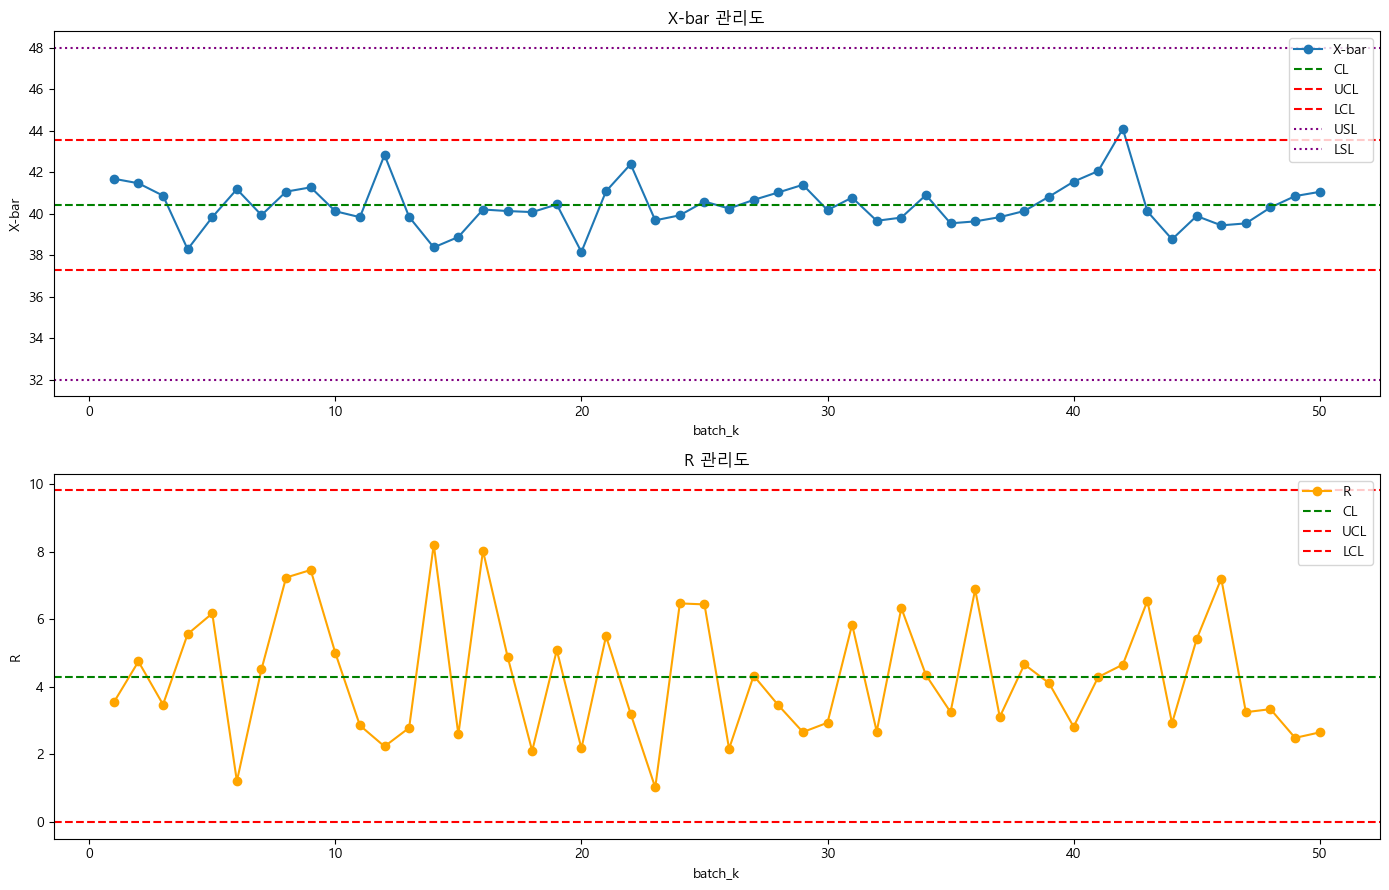

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
ax1 = axes[0] 
ax2 = axes[1] 

# X바 관리도 그리기
ax1.plot(df['batch_k'], df['X_bar'], marker='o', label='X-bar')
ax1.axhline(x_bar_center, color='green', linestyle='--', label='CL')
ax1.axhline(x_bar_UCL, color='red', linestyle='--', label='UCL')
ax1.axhline(x_bar_LCL, color='red', linestyle='--', label='LCL')
ax1.axhline(USL, color='purple', linestyle=':', label='USL')
ax1.axhline(LSL, color='purple', linestyle=':', label='LSL')
ax1.set_title('X-bar 관리도')
ax1.set_xlabel('batch_k')
ax1.set_ylabel('X-bar')
ax1.legend()

# R관리도 그리기
ax2.plot(df['batch_k'], df['R'], marker='o', color='orange', label='R')
ax2.axhline(r_center, color='green', linestyle='--', label='CL')
ax2.axhline(r_UCL, color='red', linestyle='--', label='UCL')
ax2.axhline(r_LCL, color='red', linestyle='--', label='LCL')
ax2.set_title('R 관리도')
ax2.set_xlabel('batch_k')
ax2.set_ylabel('R')
ax2.legend()

plt.tight_layout()
plt.show()

In [15]:
flagged_index = []

In [16]:
increasing_count = 1 

In [17]:
for i in range(1, len(df)): 
    current_value = df['X_bar'].iloc[i] 
    previous_value = df['X_bar'].iloc[i-1] 
    if current_value> previous_value:
        increasing_count += 1
    else:
        increasing_count = 1
    if increasing_count>=6:
        flagged_index.append(i)

In [18]:
print(flagged_index)

[39, 40, 41]


In [19]:
flagged_batches = df.loc[flagged_index, 'batch_k'].tolist()
print("이상 신호가 감지된 배치 번호:", flagged_batches)

이상 신호가 감지된 배치 번호: [40, 41, 42]


"6개의 점이 연속으로 증가했다"는 걸 확인하려면 점이 6개 다 모여야 확정할 수 있다.35,36,37,38,39,40 — 이렇게 6개가 다 쌓인 시점이 바로 batch 40이다.

In [20]:
start_index = flagged_index[0]-5
end_index = flagged_index[-1]

print(start_index, end_index)

34 41


In [21]:
start_batch = df.loc[start_index, 'batch_k']
end_batch = df.loc[end_index, 'batch_k']

print(start_batch, end_batch)

35 42


In [22]:
anomaly_batches = list(range(start_batch, end_batch+1))
print("이상구간 배치 번호:", anomaly_batches)

이상구간 배치 번호: [35, 36, 37, 38, 39, 40, 41, 42]


In [23]:
df['is_trend_anomaly'] = df['batch_k'].isin(anomaly_batches)

In [24]:
df.head()

,batch_k,보닛,도어,지붕,트렁크,X_Sum,X_bar,R,is_anomaly_zone,스프레이압력,담당조,부스온도_실측,온도,is_trend_anomaly
0,1,40.932,40.158,43.700,41.970,166.760,41.69000,3.542,False,고압,B조,23.87,정상,False
1,2,38.730,41.286,42.390,43.479,165.885,41.47125,4.749,False,저압,B조,23.92,정상,False
2,3,42.164,38.687,41.227,41.412,163.490,40.87250,3.477,False,저압,A조,23.76,정상,False
3,4,36.522,36.308,41.867,38.457,153.154,38.28850,5.559,False,고압,C조,22.71,정상,False
4,5,39.792,36.399,40.584,42.570,159.345,39.83625,6.171,False,중압,A조,22.81,정상,False


In [25]:
anomaly_df = df[df['is_trend_anomaly'] == True]
print(anomaly_df)

    batch_k      보닛      도어      지붕     트렁크    X_Sum     X_bar      R  \
34       35  38.086  41.338  39.653  39.081  158.158  39.53950  3.252   
35       36  39.969  38.440  43.500  36.622  158.531  39.63275  6.878   
36       37  39.012  38.050  41.129  41.159  159.350  39.83750  3.109   
37       38  41.166  36.688  41.336  41.350  160.540  40.13500  4.662   
38       39  40.951  38.046  42.156  42.146  163.299  40.82475  4.110   
39       40  40.206  40.314  43.027  42.648  166.195  41.54875  2.821   
40       41  44.722  41.121  41.971  40.433  168.247  42.06175  4.289   
41       42  45.190  41.591  43.353  46.248  176.382  44.09550  4.657   

    is_anomaly_zone 스프레이압력 담당조  부스온도_실측  온도  is_trend_anomaly  
34            False     중압  A조    22.65  정상              True  
35             True     중압  C조    22.95  정상              True  
36             True     고압  B조    23.30  정상              True  
37             True     고압  A조    24.49  정상              True  
38             True   

In [26]:
normal_df = df[df['is_trend_anomaly'] == False]
print(normal_df)

    batch_k      보닛      도어      지붕     트렁크    X_Sum     X_bar      R  \
0         1  40.932  40.158  43.700  41.970  166.760  41.69000  3.542   
1         2  38.730  41.286  42.390  43.479  165.885  41.47125  4.749   
2         3  42.164  38.687  41.227  41.412  163.490  40.87250  3.477   
3         4  36.522  36.308  41.867  38.457  153.154  38.28850  5.559   
4         5  39.792  36.399  40.584  42.570  159.345  39.83625  6.171   
5         6  41.430  40.465  41.676  41.164  164.735  41.18375  1.211   
6         7  37.700  38.585  41.237  42.217  159.739  39.93475  4.517   
7         8  42.705  37.216  44.447  39.902  164.270  41.06750  7.231   
8         9  42.867  36.025  42.729  43.479  165.100  41.27500  7.454   
9        10  40.864  37.564  42.567  39.498  160.493  40.12325  5.003   
10       11  39.773  38.670  41.528  39.371  159.342  39.83550  2.858   
11       12  41.837  41.871  44.075  43.566  171.349  42.83725  2.238   
12       13  40.097  38.243  41.031  40.020  159.39

In [27]:
print("이상구간 개수:", len(anomaly_df))
print("정상구간 개수:", len(normal_df))

이상구간 개수: 8
정상구간 개수: 42


In [28]:
from scipy.stats import shapiro

stat, p = shapiro(normal_df['X_bar'])
print("정상구간 정규성 검정 p-value:", p)

정상구간 정규성 검정 p-value: 0.47331027490720656


In [29]:
stat,p1 = shapiro(df['X_bar'])
print("전체구간 정규성 검정 p-value:", p1)

전체구간 정규성 검정 p-value: 0.07376613458055427


정상구간 정규성 검정 결과 p-value가 유의수준 0.05보다 크므로 정상구간 데이터가 정규분포를 따른다고 볼 수 있습니다.
그러므로 이어지는 Cp / Cpk 계산이 타당합니다.

다만 전체구간 정규성 검정 결과 p-value가 정상구간 대비 뚜렷하게 약화되었습니다.
이는 서로 다른 두 공정(정상/이상)이 혼합되어 나타난 결과로 해석되며, 전체구간 Cp/Cpk는 참고용 비교 지표로만 활용해야합니다.

normal_df만 사용해서 안정구간 기준 R바를 다시 구합니다.

In [30]:
r_bar_normal = normal_df['R'].mean()
print(r_bar_normal)

4.31152380952381


In [31]:
d2 = 2.059

In [32]:
sigma_hat = r_bar_normal / d2
print(sigma_hat)

2.0939892226924766


In [33]:
x_barbar_normal = normal_df['X_bar'].mean()
print(x_barbar_normal)

40.30682142857143


In [34]:
print("정상구간 R바:", r_bar_normal)
print("정상구간 x바바:", x_barbar_normal)
print("표준편차 추정치:", sigma_hat)

정상구간 R바: 4.31152380952381
정상구간 x바바: 40.30682142857143
표준편차 추정치: 2.0939892226924766


정상구간만 포함한 Cp와 Cpk를 계산합니다

In [35]:
Cp = (USL-LSL) / (6 * sigma_hat)
print(Cp)

1.2734863378321664


In [36]:
Cpk_upper = (USL-x_barbar_normal) / (3 * sigma_hat)
Cpk_lower = (x_barbar_normal - LSL) / (3 * sigma_hat)

In [37]:
Cpk = min(Cpk_upper, Cpk_lower)

In [38]:
print("정상구간 Cp:", Cp)
print("정상구간 Cpk:", Cpk)

정상구간 Cp: 1.2734863378321664
정상구간 Cpk: 1.224644725652183


이상구간까지 포함한 Cp와 Cpk를 계산하여 위의 값들과 비교합니다.

In [39]:
r_bar_all = df['R'].mean()
x_barbar_all = df['X_bar'].mean()
sigma_hat_all = r_bar_all / d2

In [40]:
Cp_all = (USL-LSL) / (6 * sigma_hat_all)
print(Cp_all)

1.2777193423375626


In [41]:
Cpk_upper_all = (USL-x_barbar_all) / (3 * sigma_hat_all)
Cpk_lower_all = (x_barbar_all - LSL) / (3 * sigma_hat_all)

In [42]:
Cpk_all = min(Cpk_upper_all, Cpk_lower_all)

In [43]:
print("전체구간(이상구간 포함) Cp:", Cp_all)
print("전체구간(이상구간 포함) Cpk:", Cpk_all)

전체구간(이상구간 포함) Cp: 1.2777193423375626
전체구간(이상구간 포함) Cpk: 1.2120381795447004


Cp/Cpk 분석에서 '산포 문제가 아니라 평균이 이동한 문제'라는 걸 확인했으니, 
이제 ANOVA로 그 이동의 원인이 되는 요인을 통계적으로 찾아내는 단계입니다.

In [44]:
from scipy import stats

In [45]:
f_stat, p_value = stats.f_oneway(df['보닛'], df['도어'], df['지붕'], df['트렁크'])

In [46]:
print("F값:", f_stat)
print("p_value:", p_value)

F값: 24.320614492612965
p_value: 2.0119323824161268e-13


p-value가 0.05보다 매우 작으므로 결과가 유의미 했으나, 이는 스프레이 도장 특성상 위치별/각도 차이에서 비롯되는 구조적 특성이므로 특정 시점부터 발생하는 이상신호와는 성격이 다른 변동입니다.

In [47]:
groups = df.groupby("스프레이압력")

In [48]:
low = groups.get_group('저압')['X_bar']
mid = groups.get_group('중압')['X_bar']
high = groups.get_group('고압')['X_bar']

In [49]:
print(low)

1     41.47125
2     40.87250
5     41.18375
6     39.93475
11    42.83725
15    40.20600
16    40.13225
17    40.08075
18    40.44925
21    42.39375
23    39.92700
25    40.25350
28    41.39825
31    39.66225
38    40.82475
40    42.06175
48    40.85300
Name: X_bar, dtype: float64


In [50]:
f_stat, p_value = stats.f_oneway(low, mid, high)

In [51]:
print("F값:", f_stat)
print("p_value:", p_value)

F값: 2.716289070729864
p_value: 0.07650171331567833


p-value가 0.05보다 크므로 스프레이 압력에 따라 두께가 다르다고 볼 유의미한 증거가 없습니다.

In [52]:
groups = df.groupby("담당조")

In [53]:
A_group = groups.get_group("A조")['X_bar']
B_group = groups.get_group("B조")['X_bar']
C_group = groups.get_group("C조")['X_bar']

In [54]:
f_stat, p_value = stats.f_oneway(A_group, B_group, C_group)

In [55]:
print("F값:", f_stat)
print("p_value:", p_value)

F값: 0.08494294407009476
p_value: 0.918705379740143


p-value가 0.05보다 크므로 담당조에 따라 두께가 다르다고 볼 유의미한 증거가 없습니다.

In [56]:
groups = df.groupby("온도")

In [57]:
normal_tem = groups.get_group("정상")['X_bar']
high_tem = groups.get_group("고온")['X_bar']

In [58]:
f_stat, p_value = stats.f_oneway(normal_tem, high_tem)

In [59]:
print("F값:", f_stat)
print("p_value:", p_value)

F값: 15.416003756719363
p_value: 0.0002749993648663047


p-value가 0.05보다 현저히 작으므로 온도에 따라 두께까 달라진다고 볼 수 있는 유의미한 결과가 나왔습니다.

이제부터 연속형 데이터인 부스온도_실측의 회귀분석/산점도 분석을 실행합니다.

In [60]:
from scipy.stats import linregress

In [61]:
slope, intercept, r_value, p_value, std_err = linregress(df['부스온도_실측'], df['X_bar'])

In [62]:
print("기울기(slope):", slope)
print("절편(intercept):", intercept)
print("결정계수(R^2):", r_value**2)
print("p-value:", p_value)

기울기(slope): 0.7850480612883902
절편(intercept): 22.079111692018028
결정계수(R^2): 0.5039034550752252
p-value: 7.821519021970719e-09


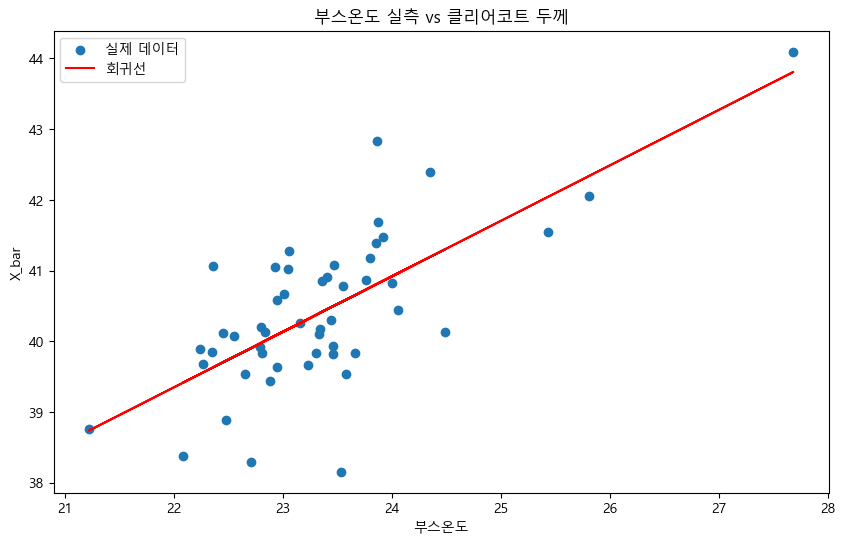

In [63]:
plt.figure(figsize=(10,6))
plt.scatter(df['부스온도_실측'], df['X_bar'], label = '실제 데이터')

x = df['부스온도_실측']
y = intercept + slope * x
plt.plot(x, y, color='red', label='회귀선')

plt.title('부스온도 실측 vs 클리어코트 두께')
plt.xlabel('부스온도')
plt.ylabel('X_bar')
plt.legend()
plt.show()

결정계수를 근거로 부스온도_실측이 두께 변화의 절반을 설명하고, p-value가 극단적으로 낮으므로 
부스온도 실측 값이 클리어코트 두께에 실제로 영향을 주고 있다고 분석했습니다.

**종합 해석과 개선안**

**핵심 발견**

- 관리도에서는 batch 40~42에서 6점 연속증가 이상신호를 감지했습니다. 실제 시작점과 이상감지 지점 간에 탐지 지연이 존재함을 확인했습니다.

- Cp/Cpk 수치에서는 Cpk만 소폭 하락하는 패턴을 보였으며 이는 산포형 이상이 아닌 공정 중심 이동형 이상임을 파악했습니다.

- ANOVA 분석 결과 4개 요인 중 패널위치와 부스온도 요인이 유의미했으나, 패널위치는 도장 공정의 구조적 특성으로 파악되어
원인에서 제외했고, 부스온도만이 이번 이상신호의 실질적 원인으로 확인되었습니다.

- 연속형 회귀분석으로 교차검증한 결과 동일한 결론을 얻었습니다.

**개선 제안**

- 실시간 온도 모니터링 체계 구축 및 명확한 임계값 설정으로 조기 대응을 제안합니다.

- 온도 변동을 통제하면 Cpk가 안정적 관리 기준인 1.33 이상으로 개선될 것을 기대합니다.
